In [1]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [2]:
PROMETHEUS_URL = "http://178.104.69.73:9090"
TIME_WINDOW_MINUTES = 30
END = datetime.now(timezone.utc)
START = END - timedelta(minutes=TIME_WINDOW_MINUTES)
STEP = '5s'
JOB = "chat-monolith"

In [3]:
connection_status = test_connection(PROMETHEUS_URL)
print('Connected: {}'.format(connection_status))

Connected: True


In [4]:
proc_cpu = prom_query_range(
    f'process_cpu_usage{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
ws_active_sessions = prom_query_range(
    f'chat_ws_active_sessions{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
ws_users = prom_query_range(
    f'chat_ws_active_users{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
vus_http_senders = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="http_senders"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
vus_ws_receivers = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="ws_receivers"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
ws_lat = prom_query_range(
    'k6_ws_delivery_latency_ms_p99',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)

In [5]:
def normalize(df):
    s = df.iloc[:, 0]  # take first column (your metric)
    return (s - s.min()) / (s.max() - s.min())

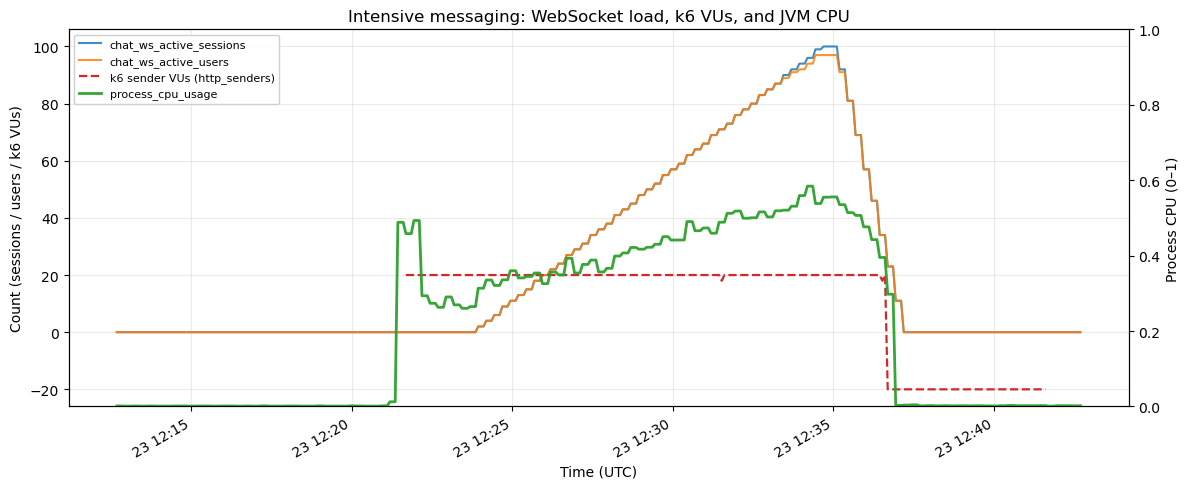

In [6]:
# Left: server metrics + k6 VUs (senders ~flat, receivers ramp) | Right: CPU
fig, ax1 = plt.subplots(figsize=(12, 5))

if not ws_active_sessions.empty:
    ws_active_sessions.iloc[:, 0].plot(ax=ax1, color="tab:blue", label="chat_ws_active_sessions", alpha=0.85)
    
if not ws_users.empty:
    ws_users.iloc[:, 0].plot(ax=ax1, color="tab:orange", label="chat_ws_active_users", alpha=0.85)
    
if not vus_http_senders.empty:
    vus_http_senders.iloc[:, 0].plot(
        ax=ax1, color="tab:red", linestyle="--", linewidth=1.6, label="k6 sender VUs (http_senders)"
    )

ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Count (sessions / users / k6 VUs)")
ax1.set_title("Intensive messaging: WebSocket load, k6 VUs, and JVM CPU")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
if not proc_cpu.empty:
    proc_cpu.iloc[:, 0].plot(ax=ax2, color="tab:green", label="process_cpu_usage", linewidth=2.0, alpha=0.95)
ax2.set_ylabel("Process CPU (0–1)")
ax2.set_ylim(0, 1)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=0.92, fontsize=8)

fig.tight_layout()
plt.show()

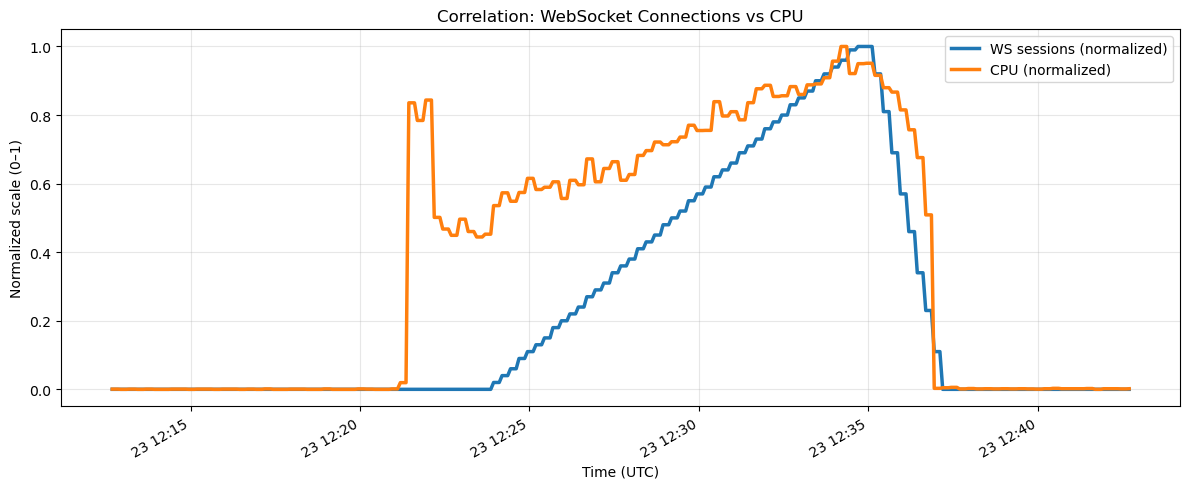

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

if not ws_active_sessions.empty:
    normalize(ws_active_sessions).plot(
        ax=ax, linewidth=2.5, label="WS sessions (normalized)"
    )

if not proc_cpu.empty:
    normalize(proc_cpu).plot(
        ax=ax, linewidth=2.5, label="CPU (normalized)"
    )

ax.set_title("Correlation: WebSocket Connections vs CPU")
ax.set_ylabel("Normalized scale (0–1)")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

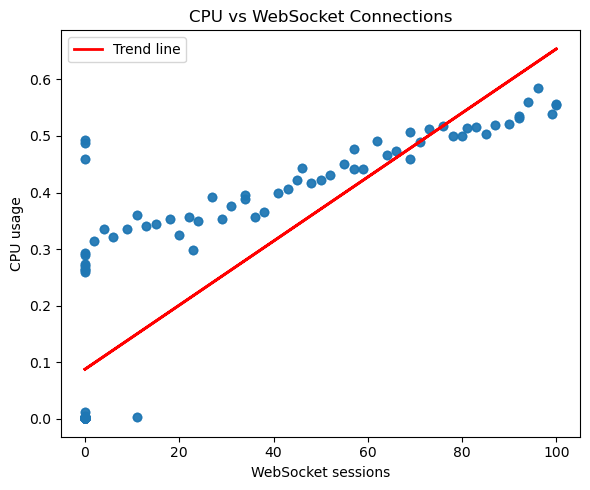

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

x = ws_active_sessions.iloc[:, 0]
y = proc_cpu.iloc[:, 0]

ax.scatter(x, y, alpha=0.6)

# Regression line (different color)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), linewidth=2, color="red", label="Trend line")

ax.set_xlabel("WebSocket sessions")
ax.set_ylabel("CPU usage")
ax.set_title("CPU vs WebSocket Connections")

ax.legend()

plt.tight_layout()
plt.show()

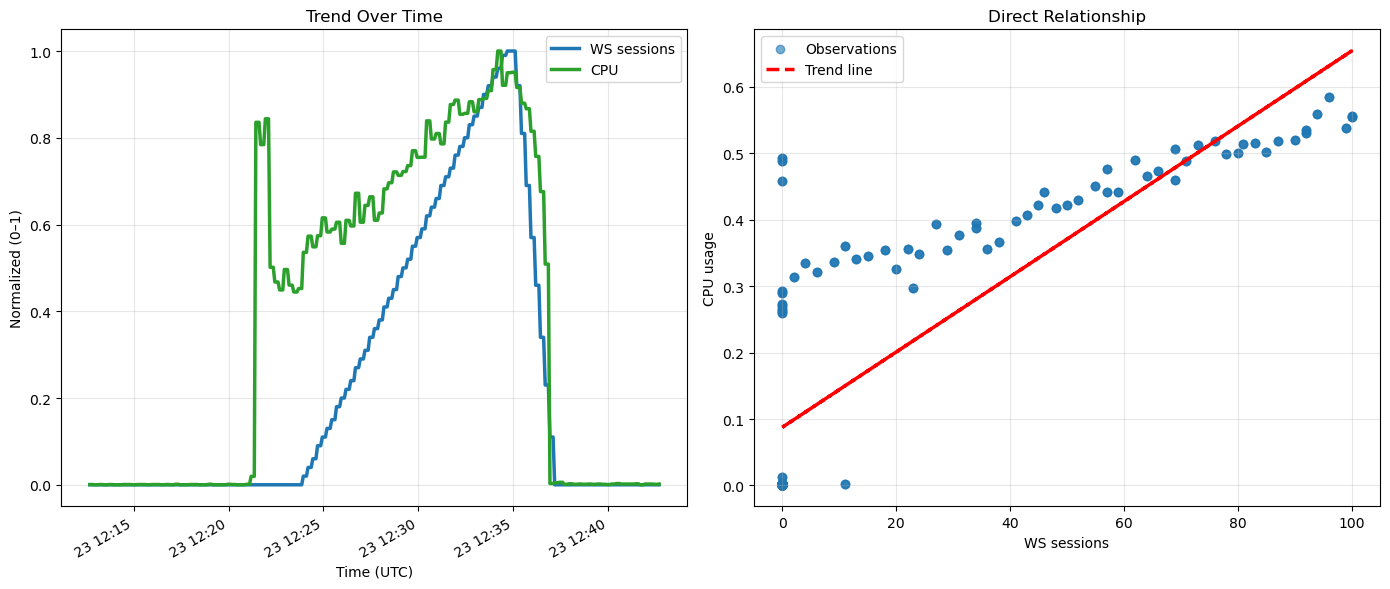

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: normalized timeline ---
if not ws_active_sessions.empty:
    normalize(ws_active_sessions).plot(
        ax=ax1, linewidth=2.5, color="tab:blue", label="WS sessions"
    )

if not proc_cpu.empty:
    normalize(proc_cpu).plot(
        ax=ax1, linewidth=2.5, color="tab:green", label="CPU"
    )

ax1.set_title("Trend Over Time")
ax1.set_ylabel("Normalized (0–1)")
ax1.set_xlabel("Time (UTC)")
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# --- Right: scatter ---
x = ws_active_sessions.iloc[:, 0]
y = proc_cpu.iloc[:, 0]

ax2.scatter(x, y, alpha=0.6, color="tab:blue", label="Observations")

# Regression line (highlighted)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax2.plot(
    x, p(x),
    linewidth=2.5,
    color="red",
    linestyle="--",
    label="Trend line"
)

ax2.set_title("Direct Relationship")
ax2.set_xlabel("WS sessions")
ax2.set_ylabel("CPU usage")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

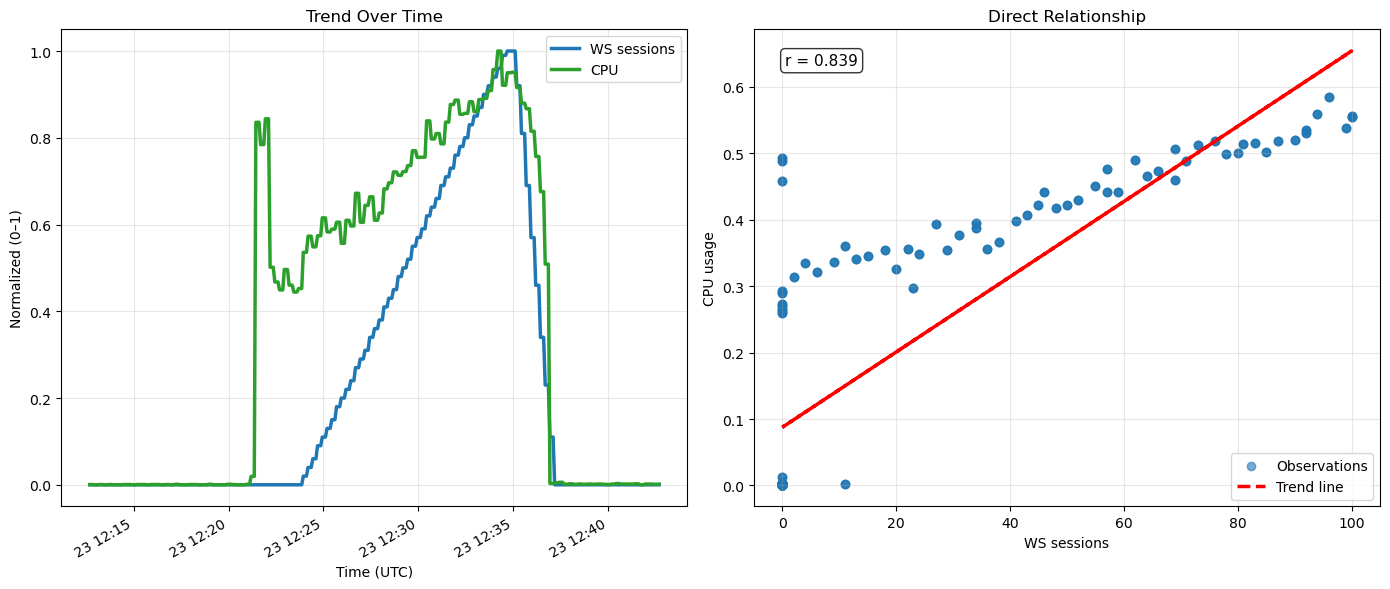

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: normalized timeline ---
if not ws_active_sessions.empty:
    normalize(ws_active_sessions).plot(
        ax=ax1, linewidth=2.5, color="tab:blue", label="WS sessions"
    )

if not proc_cpu.empty:
    normalize(proc_cpu).plot(
        ax=ax1, linewidth=2.5, color="tab:green", label="CPU"
    )

ax1.set_title("Trend Over Time")
ax1.set_ylabel("Normalized (0–1)")
ax1.set_xlabel("Time (UTC)")
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# --- Right: scatter ---
x = ws_active_sessions.iloc[:, 0]
y = proc_cpu.iloc[:, 0]

ax2.scatter(x, y, alpha=0.6, color="tab:blue", label="Observations")

# Regression line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax2.plot(
    x, p(x),
    linewidth=2.5,
    color="red",
    linestyle="--",
    label="Trend line"
)

# ✅ Correlation coefficient
corr = np.corrcoef(x, y)[0, 1]

# Display it on the plot
ax2.text(
    0.05, 0.95,
    f"r = {corr:.3f}",
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax2.set_title("Direct Relationship")
ax2.set_xlabel("WS sessions")
ax2.set_ylabel("CPU usage")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Simple graph: JVM CPU vs WS delivery latency

Uses `process_cpu_usage` (already loaded as `proc_cpu`) and k6 remote-write latency. **Set `WS_LAT_QUERY`** to the exact metric name from Prometheus (e.g. `k6_ws_delivery_latency_ms_avg` or `{__name__=~".*ws_delivery.*"}` in Explore).

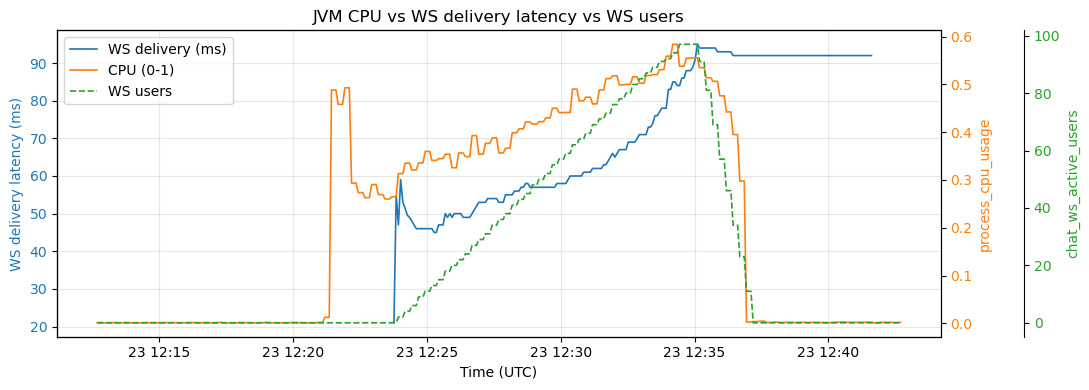

In [12]:
fig, ax1 = plt.subplots(figsize=(11, 4))

if not ws_lat.empty:
    s_lat = ws_lat.iloc[:, 0]
    ax1.plot(s_lat.index, s_lat.values, color="tab:blue", linewidth=1.2, label="WS delivery (ms)")
ax1.set_ylabel("WS delivery latency (ms)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xlabel("Time (UTC)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
if not proc_cpu.empty:
    s_cpu = proc_cpu.iloc[:, 0]
    ax2.plot(s_cpu.index, s_cpu.values, color="tab:orange", linewidth=1.2, label="CPU (0-1)")
ax2.set_ylabel("process_cpu_usage", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
# ax2.set_ylim(0, 0.8)

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
if not ws_users.empty:
    s_users = ws_users.iloc[:, 0]
    ax3.plot(s_users.index, s_users.values, color="tab:green", linewidth=1.2, linestyle="--", label="WS users")
ax3.set_ylabel("chat_ws_active_users", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
lines3, lab3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, lab1 + lab2 + lab3, loc="upper left")
plt.title("JVM CPU vs WS delivery latency vs WS users")
plt.tight_layout()
plt.show()